In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

%config InlineBackend.figure_formats = ['svg']

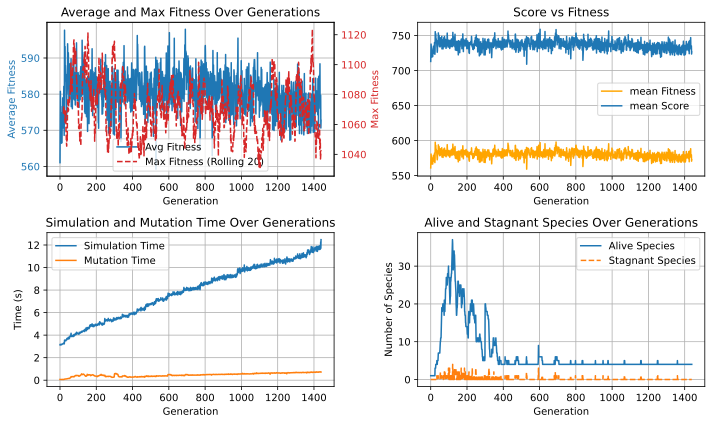

In [8]:
path = r'C:\Users\hirot\Documents\2048_NEAT\logs\actual_logs\2025-12-25_00-48-59.v3.txt'
with open(path, 'r') as f:
    log_data = f.read()

# Convert log data into a list of dictionaries
lines = log_data.strip().split('\n')
data = [eval(line) for line in lines]

# Create a pandas DataFrame
df = pd.DataFrame(data)

# Create a 2x2 subplot for all the graphs
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Assuming 'axes' is your subplot array and 'df' is your DataFrame
ax1 = axes[0, 0]

# Plot Average Fitness on the left axis
color = 'tab:blue'
ax1.set_xlabel("Generation")
ax1.set_ylabel("Average Fitness", color=color)
line1 = ax1.plot(df["current_gen"], df["avg_fitness"], label="Avg Fitness", color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot Max Fitness on the right axis
color = 'tab:red'
ax2.set_ylabel("Max Fitness", color=color)
# line2 = ax2.plot(df["current_gen"], df["max_fitness"], label="Max Fitness", color=color, alpha=0.5)

# Plot Rolling Average for Max Fitness on the right axis
rolling_max = df["max_fitness"].rolling(window=20).mean()
line3 = ax2.plot(df["current_gen"], rolling_max, label="Max Fitness (Rolling 20)", color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Set Title
ax1.set_title("Average and Max Fitness Over Generations")

# Combine legends from both axes
# lines = line1 + line2 + line3
lines = line1 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

# Plot max_fitness over generations
axes[0, 1].plot(df["current_gen"], df['avg_fitness'], label="mean Fitness", color="orange")
# axes[0, 1].plot(df["current_gen"], df["VMS"] / (1024 ** 1), label="VMS", color="blue")
axes[0, 1].plot(df["current_gen"], df["avg_score"], label="mean Score")
axes[0, 1].set_title("Score vs Fitness")
axes[0, 1].set_xlabel("Generation")
# axes[0, 1].set_ylabel("Mem Usage (GB)")
axes[0, 1].grid()
axes[0, 1].legend()

# Plot sim_time and mutate_time over generations (combined graph)
axes[1, 0].plot(df["current_gen"], df["sim_time"], label="Simulation Time")
axes[1, 0].plot(df["current_gen"], df["mutate_time"], label="Mutation Time")
axes[1, 0].set_title("Simulation and Mutation Time Over Generations")
axes[1, 0].set_xlabel("Generation")
axes[1, 0].set_ylabel("Time (s)")
axes[1, 0].grid()
axes[1, 0].legend()

# Plot alive_species and stagnant_species over generations (combined graph)
axes[1, 1].plot(df["current_gen"], df["alive_species"], label="Alive Species")
axes[1, 1].plot(df["current_gen"], df["stagnant_species"], label="Stagnant Species", linestyle="--")
axes[1, 1].set_title("Alive and Stagnant Species Over Generations")
axes[1, 1].set_xlabel("Generation")
axes[1, 1].set_ylabel("Number of Species")
axes[1, 1].grid()
axes[1, 1].legend()

# Adjust layout
plt.tight_layout()
plt.show()


In [33]:
# tourney_probs = np.array([(99 - i) * (98 - i) for i in range(0, 98)] + [0, 0])
# tourney_probs = tourney_probs / sum(tourney_probs)

# roulette_probs = np.array([np.e**(i/100) for i in range(100, 0, -1)])
# roulette_probs = roulette_probs / sum(roulette_probs)
# len(tourney_probs), len(roulette_probs)

# plt.bar(height = tourney_probs, x = np.array(range(1, 101)), alpha = 0.7, label = 'Tourney Method')
# plt.bar(height = roulette_probs, x = np.array(range(1, 101)), alpha = 0.7, label = 'Roulette Method')
# plt.legend()
# plt.xlabel('Rank (Rank 1 = Best Individual)')
# plt.ylabel('Selection Probability')
# plt.title('Selection Probability as Parent by Rank')